In [1]:
import pandas as pd
significant_degs = pd.read_csv('breast_cancer_significant_DEGS.csv', index_col=0)
significant_degs.head()
print(significant_degs.shape)



(1434, 6)


In [4]:
upregulated_genes = significant_degs[significant_degs['logFC'] > 0]
downregulated_genes = significant_degs[significant_degs['logFC'] < 0]
print(f"Number of upregulated genes: {upregulated_genes.shape[0]}")
print(f"Number of downregulated genes: {downregulated_genes.shape[0]}")

Number of upregulated genes: 542
Number of downregulated genes: 892


In [5]:
upregulated_genes_list = upregulated_genes.index.tolist()
downregulated_genes_list = downregulated_genes.index.tolist()
print(upregulated_genes_list[:5])
print(downregulated_genes_list[:5])

['RRM2', 'C16orf59', 'MYBL2', 'PITX1', 'KIF4A']
['DEFB130', 'CCDC177', 'UGT2A1', 'KLK9', 'LCN6']


In [8]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
upregulated_genes_enrichment = gp.profile(organism='hsapiens', query=upregulated_genes_list)
print(upregulated_genes_enrichment.head())
print(upregulated_genes_enrichment.shape)
downregulated_genes_enrichment = gp.profile(organism='hsapiens', query=downregulated_genes_list)
print(downregulated_genes_enrichment.head())
print(downregulated_genes_enrichment.shape)

  source      native                        name       p_value  significant  \
0  GO:BP  GO:1903047  mitotic cell cycle process  9.654849e-45         True   
1  GO:BP  GO:0000278          mitotic cell cycle  2.599436e-42         True   
2  GO:BP  GO:0022402          cell cycle process  9.545419e-41         True   
3  GO:BP  GO:0007049                  cell cycle  3.127690e-35         True   
4  GO:BP  GO:0051301               cell division  1.431653e-32         True   

                                         description  term_size  query_size  \
0  "A process that is part of the mitotic cell cy...        745         424   
1  "Progression through the phases of the mitotic...        892         424   
2  "The cellular process that ensures successive ...       1280         424   
3  "The progression of biochemical and morphologi...       1663         424   
4  "The process resulting in division and partiti...        658         424   

   intersection_size  effective_domain_size  preci

In [9]:
up_significant_enrichment = upregulated_genes_enrichment[upregulated_genes_enrichment['significant'] == True]
down_significant_enrichment = downregulated_genes_enrichment[downregulated_genes_enrichment['significant'] == True]
up_significant_enrichment = up_significant_enrichment.sort_values('p_value')
down_significant_enrichment = down_significant_enrichment.sort_values('p_value')
print(up_significant_enrichment[['name', 'p_value']].head(10))
print(down_significant_enrichment[['name', 'p_value']].head(10))


                             name       p_value
0      mitotic cell cycle process  9.654849e-45
1              mitotic cell cycle  2.599436e-42
2              cell cycle process  9.545419e-41
3                      cell cycle  3.127690e-35
4                   cell division  1.431653e-32
5          chromosome segregation  1.126143e-31
6                nuclear division  3.251029e-30
7  nuclear chromosome segregation  2.322373e-29
8                      Cell Cycle  8.849995e-29
9               organelle fission  1.419127e-28
                                             name       p_value
0                anatomical structure development  1.754209e-45
1                multicellular organismal process  4.281003e-44
2                        animal organ development  7.303424e-44
3              anatomical structure morphogenesis  9.722475e-44
4                           developmental process  4.459970e-43
5                              tissue development  7.308888e-43
6                  circu

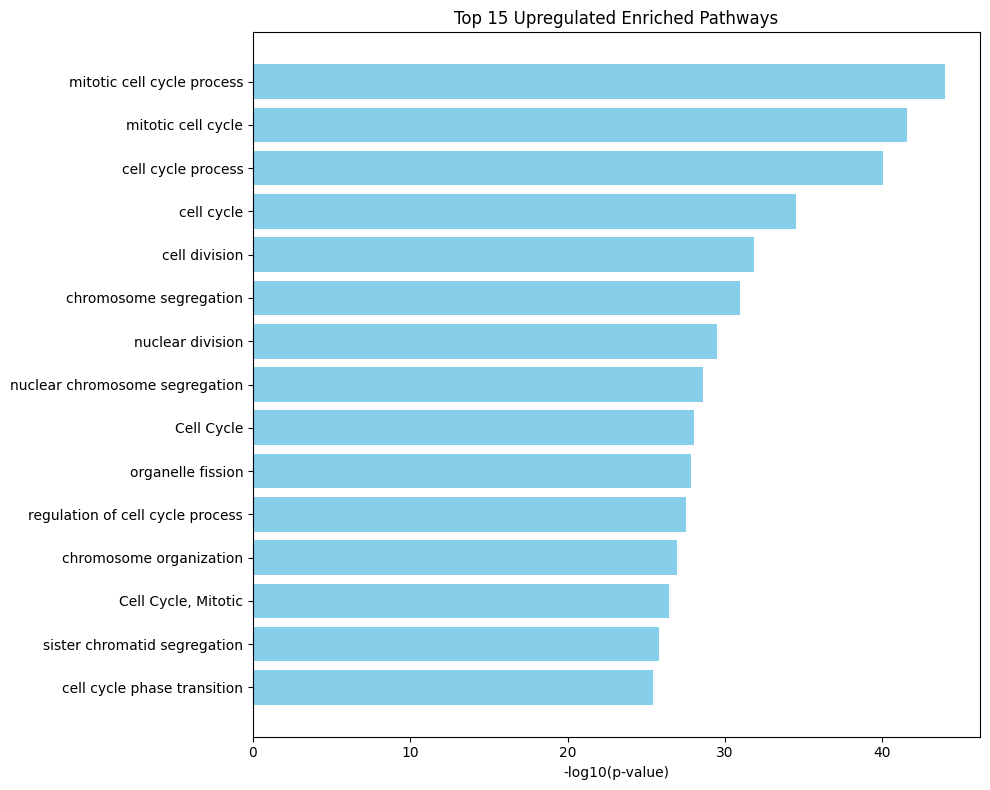

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Get top 15 upregulated genes
top_15 = up_significant_enrichment.head(15).copy()
top_15['-log10(p_value)'] = -np.log10(top_15['p_value'])

#Plotting upregulated pathways
plt.figure(figsize=(10, 8))
plt.barh(top_15['name'], top_15['-log10(p_value)'], color='skyblue')
plt.xlabel('-log10(p-value)')   
plt.title('Top 15 Upregulated Enriched Pathways')   
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_15_upregulated_pathways.png', dpi=300)
plt.show()

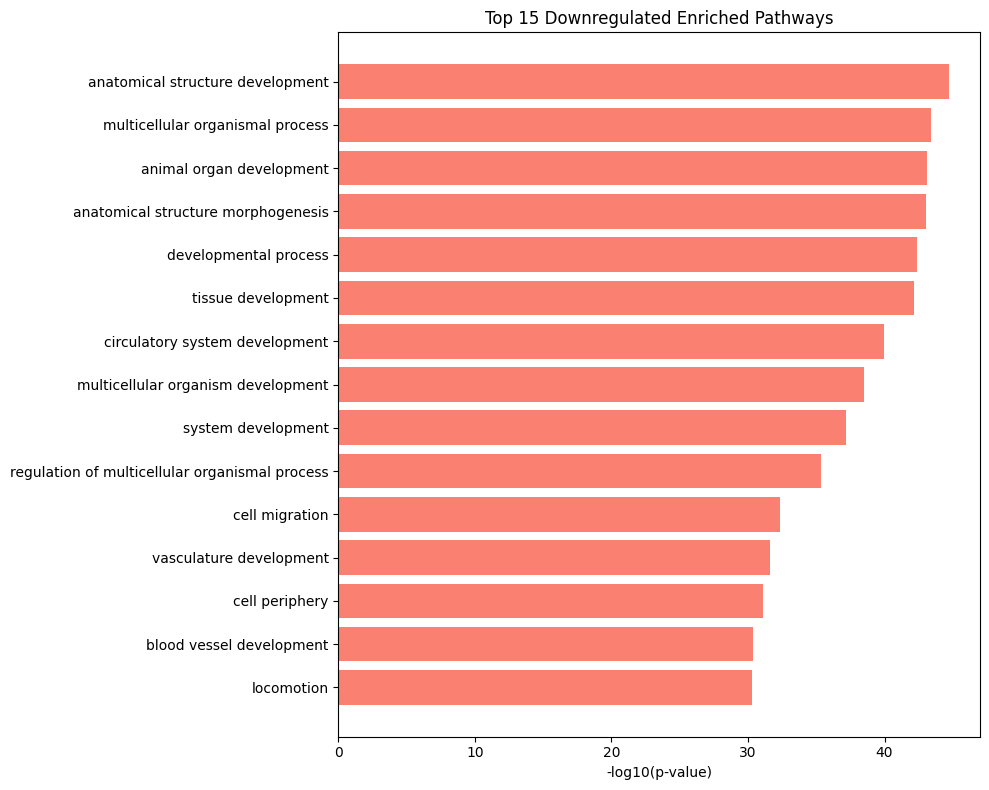

In [ ]:
#Plotting downregulated pathways
top_15_down = down_significant_enrichment.head(15).copy()
top_15_down['-log10(p_value)'] = -np.log10(top_15_down['p_value'])
plt.figure(figsize=(10, 8))
plt.barh(top_15_down['name'], top_15_down['-log10(p_value)'], color='salmon')
plt.xlabel('-log10(p-value)')       
plt.title('Top 15 Downregulated Enriched Pathways')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_15_downregulated_pathways.png', dpi=300)
plt.show()


['source', 'native', 'name', 'p_value', 'significant', 'description', 'term_size', 'query_size', 'intersection_size', 'effective_domain_size', 'precision', 'recall', 'query', 'parents']


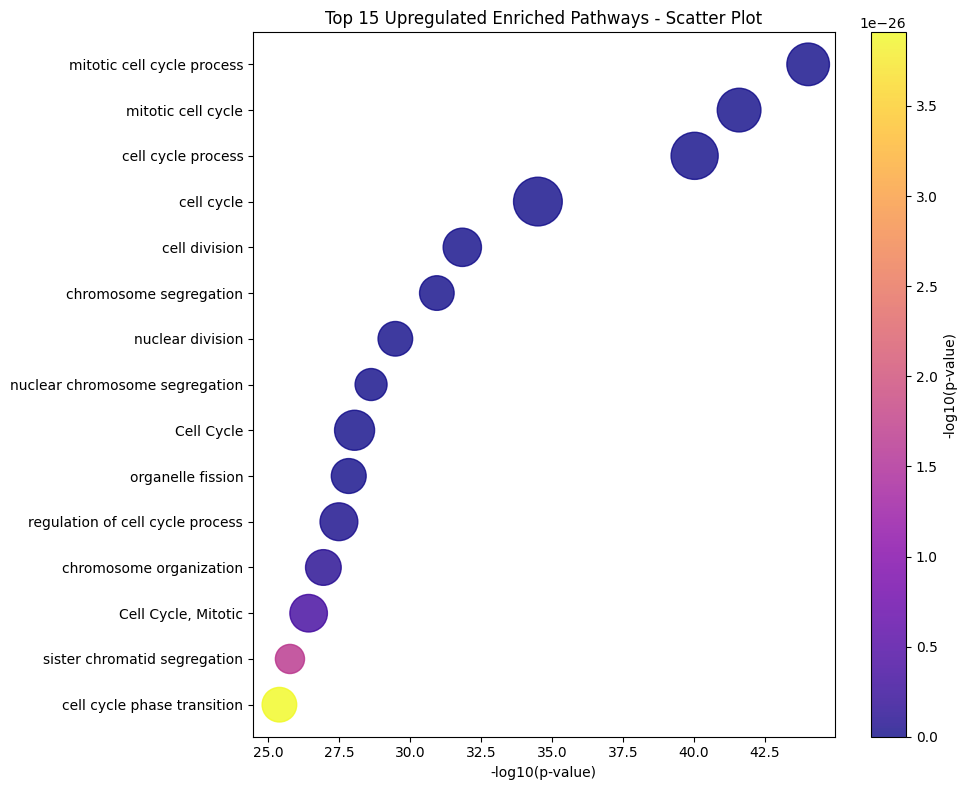

In [17]:
print(upregulated_genes_enrichment.columns.tolist())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(top_15['-log10(p_value)'], top_15['name'], s=top_15['intersection_size']*10, c=top_15['p_value'], cmap='plasma', alpha=0.8)
plt.colorbar(scatter, label='-log10(p-value)')
plt.xlabel('-log10(p-value)')
plt.title('Top 15 Upregulated Enriched Pathways - Scatter Plot')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_15_upregulated_pathways_scatter.png', dpi=300)
plt.show()

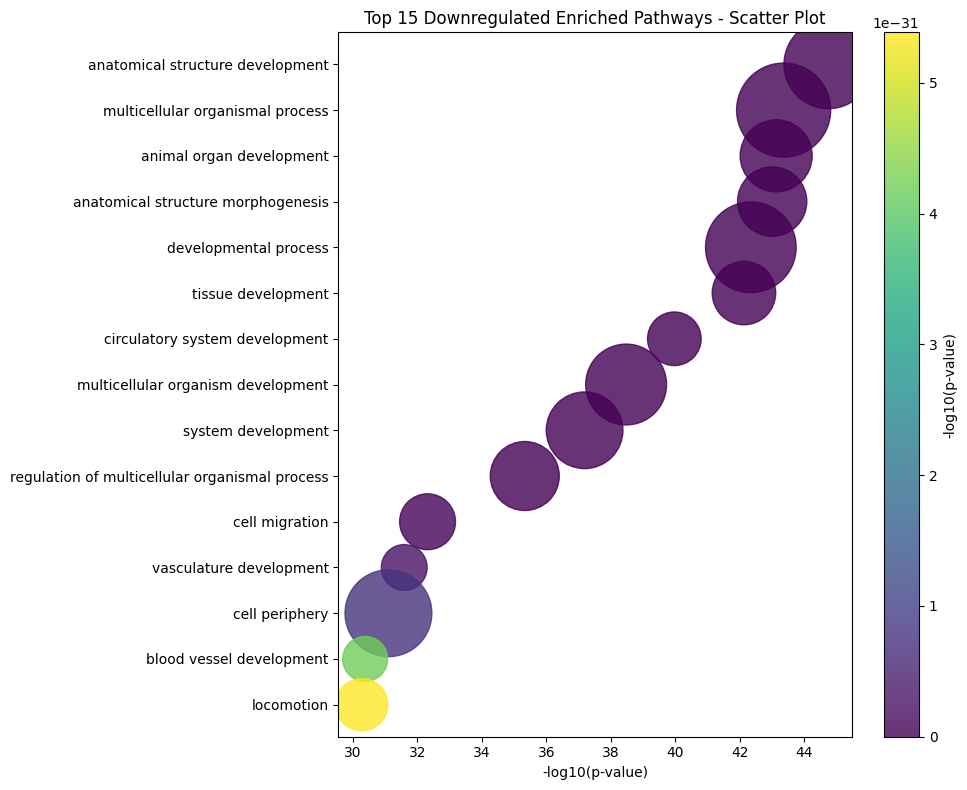

In [20]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(top_15_down['-log10(p_value)'], top_15_down['name'], s=top_15_down['intersection_size']*10, c=top_15_down['p_value'], cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='-log10(p-value)')
plt.xlabel('-log10(p-value)')
plt.title('Top 15 Downregulated Enriched Pathways - Scatter Plot')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_15_downregulated_pathways_scatter.png', dpi=300)
plt.show()